##  Employee Attrition Prediction: Logistic Regression
In this notebook, I will create Employee Attrition Prediction Models using Logistic Regression with Employee Attrition Dataset in [Playground Series Season 3, Episode 3](https://www.kaggle.com/competitions/playground-series-s3e3) and original [IBM HR Analytics Employee Attrition & Performance dataset](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset). I will do Exploratory Data Analaysis to select correlated features. I will train models for 10 folds using StratifiedKFold split strategy with different random seeds. In order to maximize the score, I will brute force searching best parameters in different folds.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
from datetime import datetime
warnings.filterwarnings("ignore")

## Configuration

In [2]:
class CFG:
    TRAIN_DATA_URL = "../input/playground-series-s3e3/train.csv"
    TEST_DATA_URL = "../input/playground-series-s3e3/test.csv"
    id_field = "id"
    target_field = "Attrition"
    n_folds = 5

## Load data

In [3]:
train = pd.read_csv(CFG.TRAIN_DATA_URL)
external_train = pd.read_csv("../input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")
external_train.rename(columns={"EmployeeNumber": CFG.id_field}, inplace=True)
external_train[CFG.target_field] = external_train[CFG.target_field].apply(lambda attribution: 1 if attribution=="Yes" else 0)
train = pd.concat([train, external_train])
train.index = list(range(len(train)))
test = pd.read_csv(CFG.TEST_DATA_URL)

## EDA

### Overall label distribution

<AxesSubplot:xlabel='Attrition', ylabel='count'>

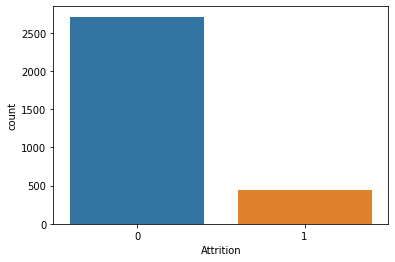

In [4]:
sns.countplot(train[CFG.target_field])

### Feature Engineering

In [5]:
train["is_young"] = (train["Age"] <= 25).astype(int)
test["is_young"] = (test["Age"] <= 25).astype(int)
train["young_and_low_daily_rate"] = ((train["Age"] <= 25) & (train["DailyRate"] < 500)).astype(int)
test["young_and_low_daily_rate"] = ((test["Age"] <= 25) & (test["DailyRate"] < 500)).astype(int)
train["OverTime"] = train["OverTime"].apply(lambda overtime: 1 if overtime == "Yes" else 0)
test["OverTime"] = test["OverTime"].apply(lambda overtime: 1 if overtime == "Yes" else 0)
train["Gender"] = train["Gender"].apply(lambda gender: 1 if gender == "Female" else 0)
test["Gender"] = test["Gender"].apply(lambda gender: 1 if gender == "Female" else 0)
train["PerformanceRating"] = train["PerformanceRating"].apply(lambda PerformanceRating: 1 if PerformanceRating == 4 else 0)
test["PerformanceRating"] = test["PerformanceRating"].apply(lambda PerformanceRating: 1 if PerformanceRating == 4 else 0)

### Infer categorical columns and numerical columns automatically
I will choose features with string type and features with numerical type with unique value between 3 to 10 as categorical features.  Besides, StandardHours, Over18 and EmployeeCount only have one unique value, these columns can be removed. Categorical features Education, EnvironmentSatisfaction, JobInvolvement, JobLevel, StockOptionLevel have different unique values bettwen train set and test set, I will handle this difference manually.

In [6]:
categorical_columns = []
numeric_columns = []
#numeric_columns = ["NumCompaniesWorked", "TrainingTimesLastYear"]
for column in train.columns:
    if column == CFG.id_field or column == CFG.target_field:
        continue
    print("=" * 50)
    print("=" * 50)
    print(f"Number of unique {column} value in training set:{train[column].nunique()}")
    print(f"Number of unique {column} value in test set:{test[column].nunique()}")
    if train[column].dtype == object:
        if len(train[column].unique()) == 1:
            print(f"{column} only have one unique value, omit this feature.")
        else:
            print("Unique value in train set:", sorted(train[column].unique()))
            print("Unique value in test set:", sorted(test[column].unique()))
            categorical_columns.append(column)
    else:
        if len(train[column].unique()) == 1:
            print(f"{column} only have one unique value, omit this feature.")
        elif len(train[column].unique()) == 2:
            numeric_columns.append(column)
            print("Unique value in train set:", sorted(train[column].unique()))
            print("Unique value in test set:", sorted(test[column].unique()))
        elif len(train[column].unique()) <= 10:
            print("Unique value in train set:", sorted(train[column].unique()))
            print("Unique value in test set:", sorted(test[column].unique()))
            if column not in numeric_columns:
                categorical_columns.append(column)
        else:
            numeric_columns.append(column)
feature_columns = numeric_columns + categorical_columns
all_columns = feature_columns + [CFG.target_field]
print(f"Categorical columns:{categorical_columns}.")
print(f"Numerical columns:{numeric_columns}.")
train.loc[train["Education"] == 15, "Education"] = 5
test.loc[test["EnvironmentSatisfaction"] == 0, "EnvironmentSatisfaction"] = 1
test.loc[test["JobInvolvement"] == 0, "JobInvolvement"] = 1
test.loc[test["JobLevel"] == 7, "JobLevel"] = 5
test.loc[test["StockOptionLevel"] == 4, "StockOptionLevel"] = 3

Number of unique Age value in training set:43
Number of unique Age value in test set:42
Number of unique BusinessTravel value in training set:3
Number of unique BusinessTravel value in test set:3
Unique value in train set: ['Non-Travel', 'Travel_Frequently', 'Travel_Rarely']
Unique value in test set: ['Non-Travel', 'Travel_Frequently', 'Travel_Rarely']
Number of unique DailyRate value in training set:901
Number of unique DailyRate value in test set:515
Number of unique Department value in training set:3
Number of unique Department value in test set:3
Unique value in train set: ['Human Resources', 'Research & Development', 'Sales']
Unique value in test set: ['Human Resources', 'Research & Development', 'Sales']
Number of unique DistanceFromHome value in training set:29
Number of unique DistanceFromHome value in test set:29
Number of unique Education value in training set:6
Number of unique Education value in test set:5
Unique value in train set: [1, 2, 3, 4, 5, 15]
Unique value in test 

### Distribution of target in different categorical features

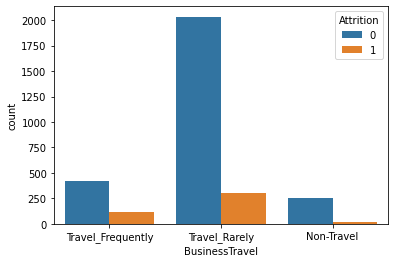

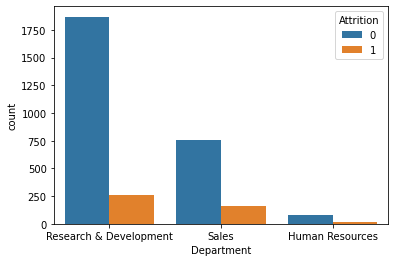

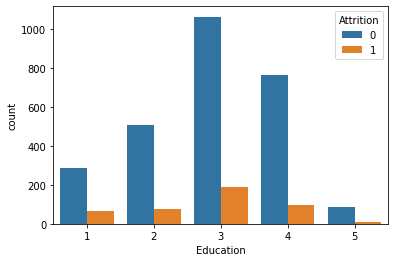

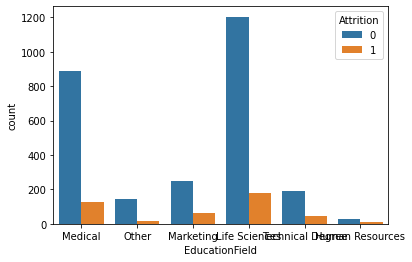

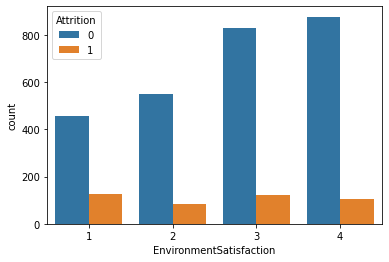

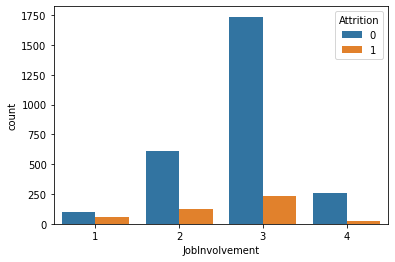

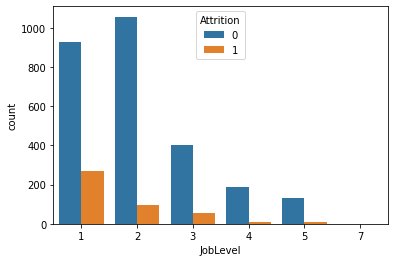

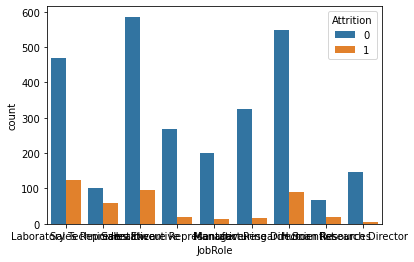

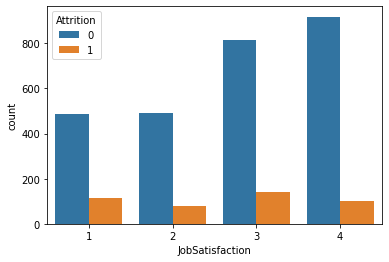

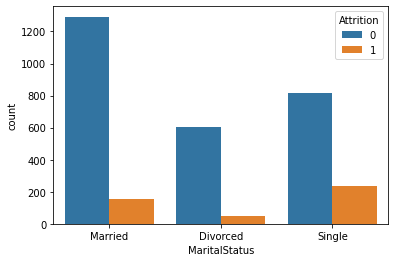

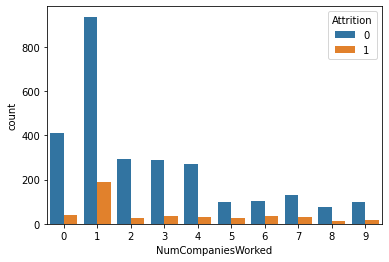

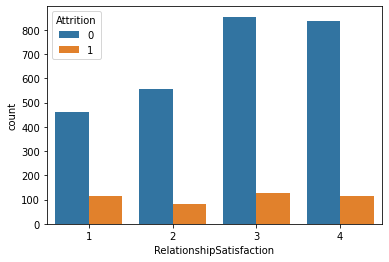

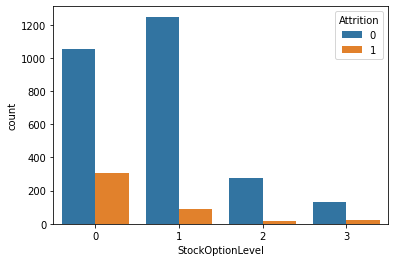

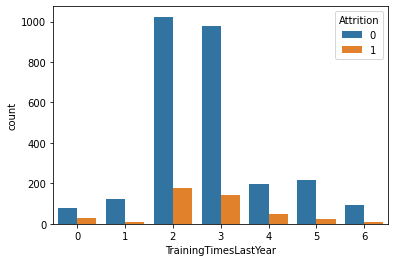

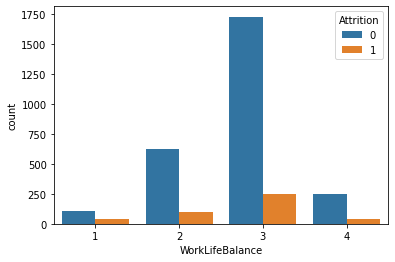

In [7]:
for column in categorical_columns:
    sns.countplot(data=train, x=column, hue=CFG.target_field)
    plt.show()

### Distribution of target in different numerical features

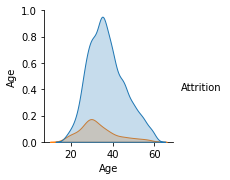

<Figure size 720x720 with 0 Axes>

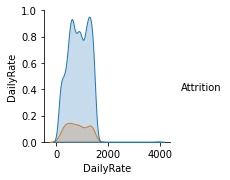

<Figure size 720x720 with 0 Axes>

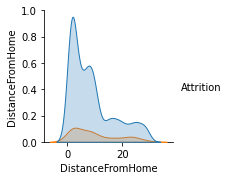

<Figure size 720x720 with 0 Axes>

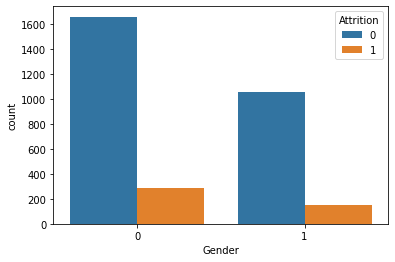

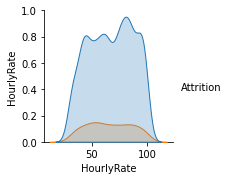

<Figure size 720x720 with 0 Axes>

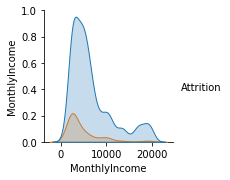

<Figure size 720x720 with 0 Axes>

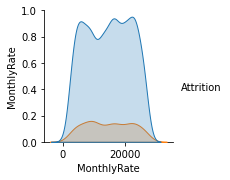

<Figure size 720x720 with 0 Axes>

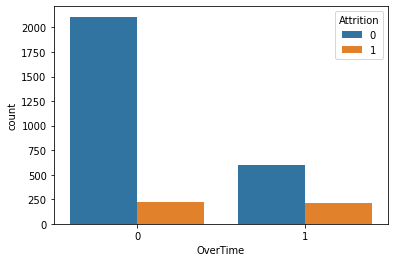

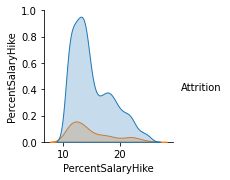

<Figure size 720x720 with 0 Axes>

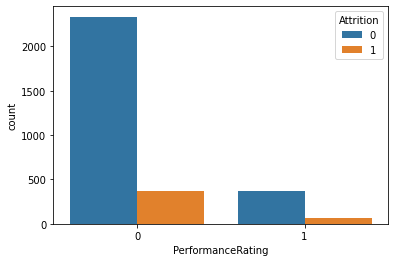

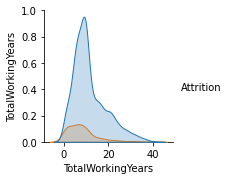

<Figure size 720x720 with 0 Axes>

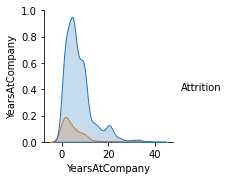

<Figure size 720x720 with 0 Axes>

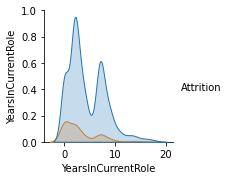

<Figure size 720x720 with 0 Axes>

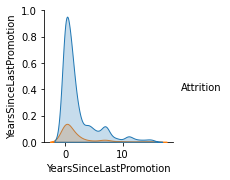

<Figure size 720x720 with 0 Axes>

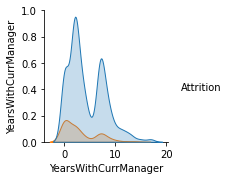

<Figure size 720x720 with 0 Axes>

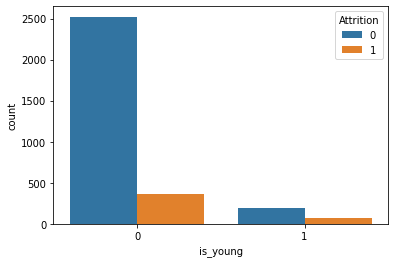

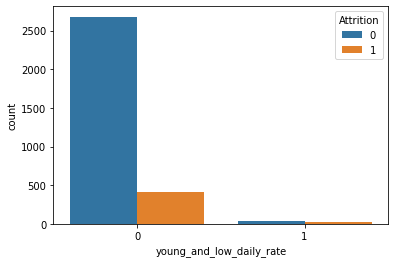

In [8]:
for column in numeric_columns:
    if train[column].nunique() <= 2:
        sns.countplot(data=train, x=column, hue=CFG.target_field)
        plt.show()
    else:
        sns.pairplot(train[[column, CFG.target_field]], hue=CFG.target_field, diag_kind="kde")
        plt.figure(figsize=(10, 10))
        plt.show()

In [9]:
test[CFG.target_field] = 0.0
data = pd.concat([train[all_columns], test[all_columns]])
data_dummy = pd.get_dummies(data, columns=categorical_columns)
train_dummy = data_dummy.iloc[:len(train)]
test_dummy = data_dummy.iloc[len(train):]
train_dummy.head()

,Age,DailyRate,DistanceFromHome,Gender,HourlyRate,MonthlyIncome,MonthlyRate,OverTime,PercentSalaryHike,PerformanceRating,...,TrainingTimesLastYear_1,TrainingTimesLastYear_2,TrainingTimesLastYear_3,TrainingTimesLastYear_4,TrainingTimesLastYear_5,TrainingTimesLastYear_6,WorkLifeBalance_1,WorkLifeBalance_2,WorkLifeBalance_3,WorkLifeBalance_4
0,36,599,24,0,42,2596,5099,1,13,0,...,0,1,0,0,0,0,0,0,1,0
1,35,921,8,0,46,2899,10778,0,17,0,...,0,0,1,0,0,0,0,0,1,0
2,32,718,26,0,80,4627,16495,0,17,0,...,0,0,1,0,0,0,0,0,1,0
3,38,1488,2,1,40,5347,13384,0,14,0,...,1,0,0,0,0,0,1,0,0,0
4,50,1017,5,1,37,19033,19805,1,13,0,...,0,0,0,0,0,0,0,0,1,0


### Correlated features

In [10]:
corr = train_dummy.corr()
correlated_columns =  list(corr[CFG.target_field][corr[CFG.target_field].abs() > 0.05].index)
correlated_columns.remove(CFG.target_field)
if CFG.id_field in correlated_columns:
    correlated_columns.remove(CFG.id_field)
print(f"Correlated features:{correlated_columns}")

Correlated features:['Age', 'DistanceFromHome', 'MonthlyIncome', 'OverTime', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'is_young', 'young_and_low_daily_rate', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Marketing', 'EnvironmentSatisfaction_1', 'EnvironmentSatisfaction_4', 'JobInvolvement_1', 'JobInvolvement_3', 'JobInvolvement_4', 'JobLevel_1', 'JobLevel_2', 'JobLevel_4', 'JobRole_Healthcare Representative', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Sales Representative', 'JobSatisfaction_1', 'JobSatisfaction_4', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single', 'NumCompaniesWorked_0', 'NumCompaniesWorked_1', 'NumCompaniesWorked_2', 'NumCompaniesWorked_6', 'RelationshipSatisfaction_1', 'StockOptionLevel_0', 'StockO

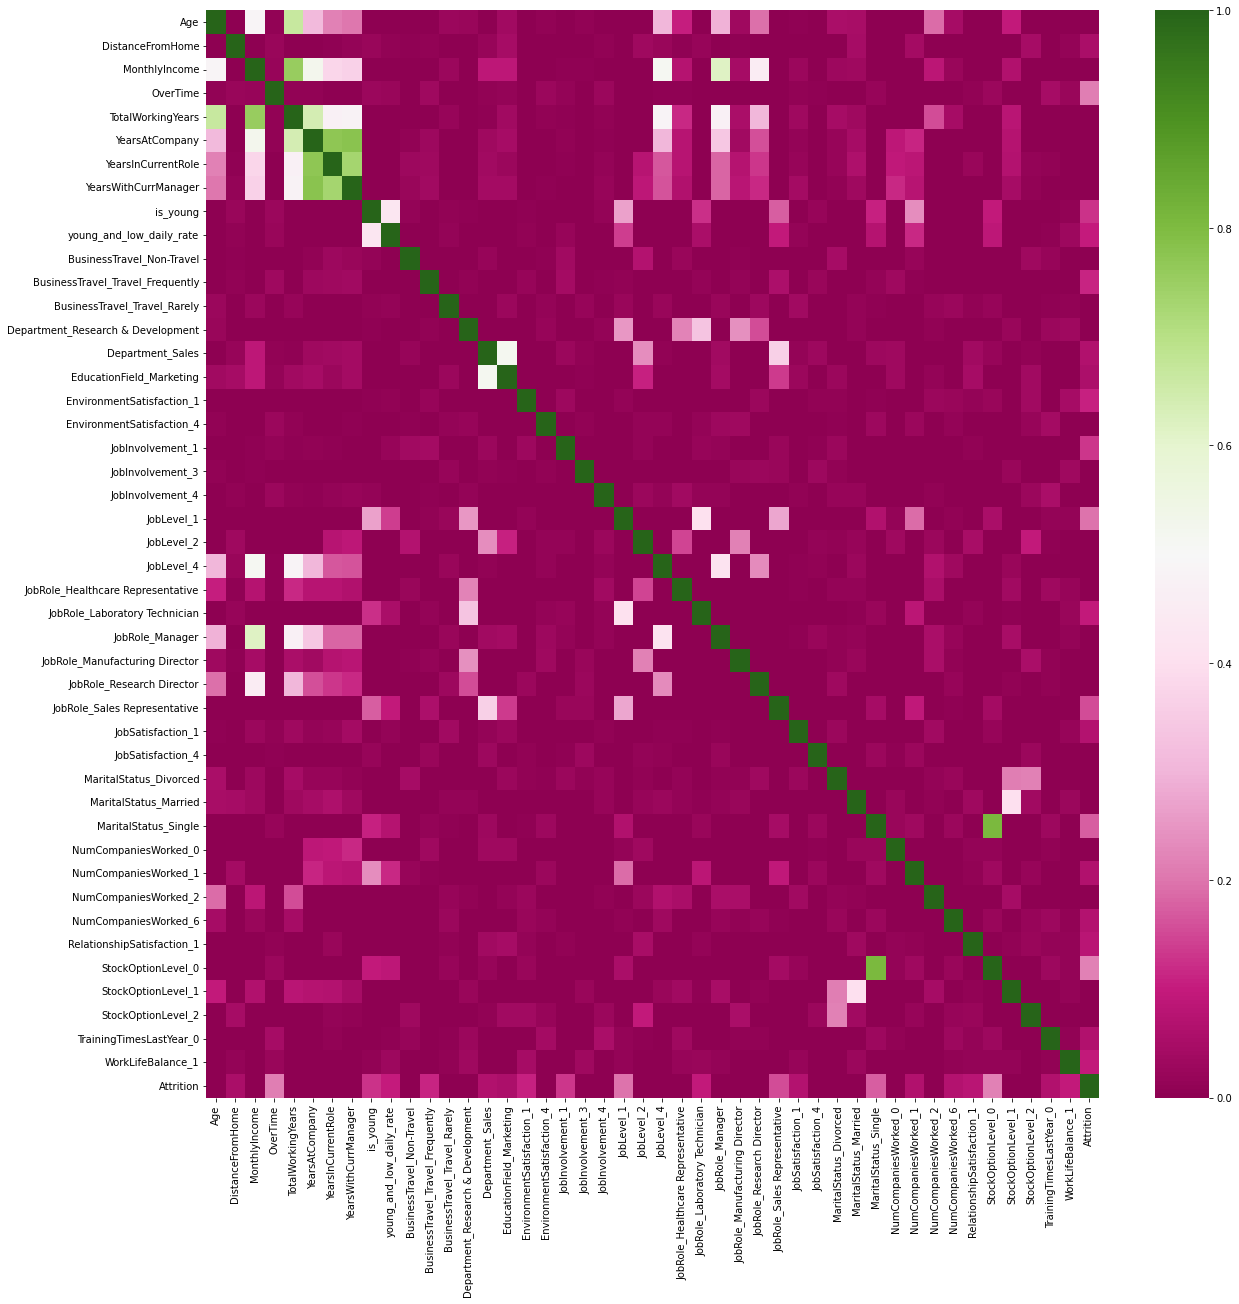

In [11]:
corr = train_dummy[correlated_columns + [CFG.target_field]].corr()
plt.figure(figsize=(20, 20))
sns.heatmap(corr, vmin=0, vmax=1.0,  cmap="PiYG")
plt.show()

In [12]:
corr[CFG.target_field].sort_values(key=lambda x: abs(x), ascending=False)

Attrition                            1.000000
StockOptionLevel_0                   0.218331
OverTime                             0.213219
JobLevel_1                           0.196145
StockOptionLevel_1                  -0.175072
MaritalStatus_Single                 0.172813
Age                                 -0.156500
JobRole_Sales Representative         0.153861
TotalWorkingYears                   -0.152672
YearsInCurrentRole                  -0.145807
MonthlyIncome                       -0.141174
YearsWithCurrManager                -0.140380
JobInvolvement_1                     0.132668
YearsAtCompany                      -0.129427
is_young                             0.127768
JobLevel_2                          -0.125598
BusinessTravel_Travel_Frequently     0.110552
EnvironmentSatisfaction_1            0.108904
young_and_low_daily_rate             0.099326
WorkLifeBalance_1                    0.097440
JobRole_Manufacturing Director      -0.095643
JobRole_Laboratory Technician     

## Searching for best parameters

In [13]:
%%time
cs = np.dot(np.array([0.01, 0.1, 1]).reshape((-1, 1)), np.arange(1, 11).reshape(1, -1)).flatten()
solvers = ['liblinear', 'lbfgs', 'sag', 'saga']
X_train, X_val = train_test_split(train_dummy, test_size=0.2, random_state=42)
y_train, y_val = X_train.pop(CFG.target_field), X_val.pop(CFG.target_field)
best_c_index = 0
best_solver_index = 0
best_score = 0
for i in range(len(cs)):
    for j in range(len(solvers)):
        model = Pipeline([
            ('preprocessor', StandardScaler()),
            ('logit', LogisticRegression(C=cs[i], solver=solvers[j], class_weight='balanced', random_state=42)),
        ])
        model.fit(X_train[correlated_columns], y_train)
        y_pred = model.predict_proba(X_val[correlated_columns])[:, 1].reshape(-1)
        score = roc_auc_score(y_val, y_pred)
        if score > best_score:
            best_score = score
            best_c_index = i
            best_solver_index = j
print(f"Best C: {cs[best_c_index]}")
print(f"Best solver: {solvers[best_solver_index]}")
print(f"Best score: {best_score}")

Best C: 0.01
Best solver: sag
Best score: 0.8672427983539095
CPU times: user 27.2 s, sys: 20.1 s, total: 47.2 s
Wall time: 14.4 s


## Modeling

Now train the model for using StratifiedKFold for 10 folds. Brute force searching best parameters for different folds. Since this dataset is very small, use different random seeds to stabilize the result. 

In [14]:
def get_best_model(X_train, y_train, X_val, y_val, random_state):
    cs = np.dot(np.array([0.01, 0.1, 1]).reshape((-1, 1)), np.arange(1, 11).reshape(1, -1)).flatten()
    solvers = ['liblinear', 'lbfgs', 'sag', 'saga']
    best_c_index = 0
    best_solver_index = 0
    best_score = 0
    best_model = None
    for i in range(len(cs)):
        for j in range(len(solvers)):
            model = Pipeline([
                ('preprocessor', StandardScaler()),
                ('logit', LogisticRegression(C=cs[i], solver=solvers[j], class_weight='balanced', random_state=random_state)),
            ])
            model.fit(X_train[correlated_columns], y_train)
            y_pred = model.predict_proba(X_val[correlated_columns])[:, 1].reshape(-1)
            score = roc_auc_score(y_val, y_pred)
            if score > best_score:
                best_score = score
                best_c_index = i
                best_solver_index = j
                best_model = model
    print(f"Best C: {cs[best_c_index]}")
    print(f"Best solver: {solvers[best_solver_index]}")
    print(f"Best score: {best_score:.5f}")
    return {
        "C": cs[best_c_index],
        "solver": solvers[best_solver_index],
        "model": best_model,
        "score": best_score
    }

In [15]:
%%time
seeds = [2, 2023, 1268]
models = []
scores = []
for seed in seeds:
    kfold =StratifiedKFold(CFG.n_folds, shuffle=True, random_state=seed)
    for fold, (train_indices, valid_indices) in enumerate(kfold.split(train_dummy, train_dummy[CFG.target_field])):
        X_train = train_dummy.iloc[train_indices]
        y_train = X_train.pop(CFG.target_field)
        X_val = train_dummy.iloc[valid_indices]
        y_val = X_val.pop(CFG.target_field)
        checkpoints = get_best_model(X_train, y_train, X_val, y_val, seed)
        model = checkpoints['model']
        score = checkpoints['score']
        models.append(model)
        scores.append(score)
    mean_score = np.mean(scores[-CFG.n_folds:])
    print(f"Average AUC for random seed {seed}: {mean_score:.5f}")
print("Average AUC: %.5f"%(np.mean(scores)))

Best C: 0.01
Best solver: lbfgs
Best score: 0.88146
Best C: 0.01
Best solver: liblinear
Best score: 0.85722
Best C: 0.01
Best solver: lbfgs
Best score: 0.84850
Best C: 0.02
Best solver: liblinear
Best score: 0.82759
Best C: 0.01
Best solver: liblinear
Best score: 0.85229
Average AUC for random seed 2: 0.85341
Best C: 0.01
Best solver: liblinear
Best score: 0.85141
Best C: 0.05
Best solver: liblinear
Best score: 0.85951
Best C: 0.01
Best solver: lbfgs
Best score: 0.84493
Best C: 0.03
Best solver: liblinear
Best score: 0.85863
Best C: 0.01
Best solver: lbfgs
Best score: 0.84710
Average AUC for random seed 2023: 0.85232
Best C: 0.02
Best solver: liblinear
Best score: 0.84714
Best C: 0.01
Best solver: liblinear
Best score: 0.83560
Best C: 0.01
Best solver: saga
Best score: 0.83302
Best C: 0.02
Best solver: liblinear
Best score: 0.86968
Best C: 0.01
Best solver: liblinear
Best score: 0.87643
Average AUC for random seed 1268: 0.85237
Average AUC: 0.85270
CPU times: user 6min 54s, sys: 5min 6

## Submission 

In [16]:
test[CFG.target_field]  = np.dot(np.array(scores), np.array([model.predict_proba(test_dummy[correlated_columns])[:, 1].reshape(-1) for model in models])) / np.sum(scores)
submission = test[[CFG.id_field, CFG.target_field]]
submission.to_csv("submission.csv", index=False)
submission.head()

,id,Attrition
0,1677,0.423365
1,1678,0.620550
2,1679,0.246953
3,1680,0.228885
4,1681,0.800650


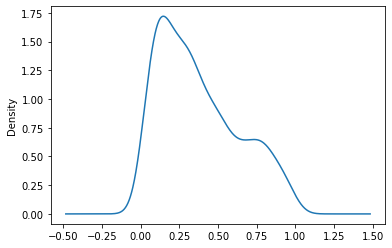

In [17]:
submission[CFG.target_field].plot(kind="kde")
plt.show()